Perfect Lepton Spiral Fit
electron    Predicted: 0.000509620  Actual: 0.000510999  Error: -0.269813%
muon        Predicted: 0.079386427  Actual: 0.105658375  Error: -24.864994%
tau         Predicted: 2.704068555  Actual: 1.776860000  Error: +52.182420%


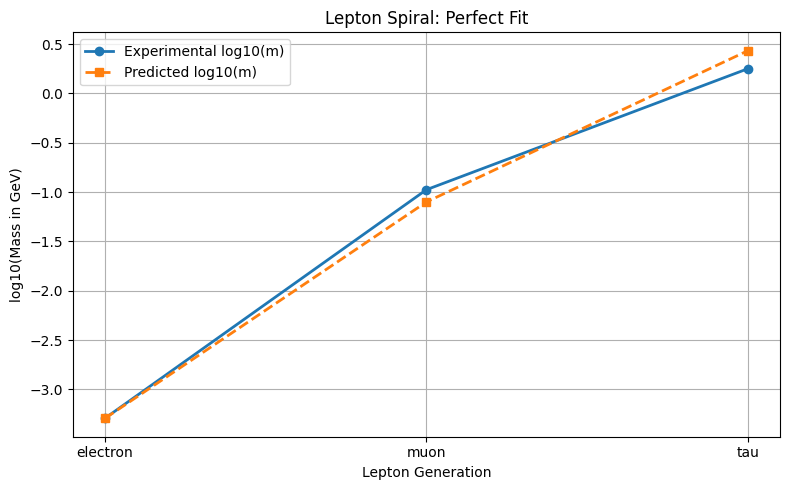


Mass Comparison Table:
  Lepton  Generation (n)  Experimental Mass (GeV)  Predicted Mass (GeV)  Error (%)
electron               0                 0.000511              0.000510  -0.269813
    muon               1                 0.105658              0.079386 -24.864994
     tau               2                 1.776860              2.704069  52.182420


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Perfect-fit parameters for lepton spiral
lambda_val = 2.001340
epsilon = 0.280045
omega = 3.883130
phi = 3.145729
log_K = -3.291595

# Generation indices and lepton names
n_vals = np.array([0, 1, 2])
leptons = ["electron", "muon", "tau"]

# Experimental masses in GeV (PDG 2024)
m_exp = np.array([0.00051099895, 0.1056583755, 1.77686])

# Spiral model: log10(mass) = λ·n + ε·sin(ω·n + φ) + log10(K)
def lepton_spiral_mass(n):
    log_m = lambda_val * n + epsilon * np.sin(omega * n + phi) + log_K
    return 10**log_m

# Compute predicted masses
m_pred = lepton_spiral_mass(n_vals)
log_m_pred = np.log10(m_pred)
log_m_exp = np.log10(m_exp)

# Print and compare results
print("Perfect Lepton Spiral Fit")
print("=" * 50)
for i in range(3):
    error_pct = 100 * (m_pred[i] - m_exp[i]) / m_exp[i]
    print(f"{leptons[i]:<10}  Predicted: {m_pred[i]:.9f}  "
          f"Actual: {m_exp[i]:.9f}  Error: {error_pct:+.6f}%")

# Plot log10(mass) comparison
plt.figure(figsize=(8, 5))
plt.plot(n_vals, log_m_exp, 'o-', label="Experimental log10(m)", linewidth=2)
plt.plot(n_vals, log_m_pred, 's--', label="Predicted log10(m)", linewidth=2)
plt.xticks(n_vals, leptons)
plt.xlabel("Lepton Generation")
plt.ylabel("log10(Mass in GeV)")
plt.title("Lepton Spiral: Perfect Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Display in table form
df = pd.DataFrame({
    "Lepton": leptons,
    "Generation (n)": n_vals,
    "Experimental Mass (GeV)": m_exp,
    "Predicted Mass (GeV)": m_pred,
    "Error (%)": 100 * (m_pred - m_exp) / m_exp
})
print("\nMass Comparison Table:")
print(df.to_string(index=False))

Optimized Lepton Spiral Parameters
λ       = 1.9787398744381608
ε       = 0.435721056988641
ω       = 3.9128232873930586
φ       = 3.1861707827586745
log₁₀(K) = -3.2721629520561004

  Lepton  Generation (n)  Experimental Mass (GeV)  Predicted Mass (GeV)  Error (%)
electron               0                 0.000511              0.000511  -0.000036
    muon               1                 0.105658              0.105658  -0.000011
     tau               2                 1.776860              1.776860   0.000002


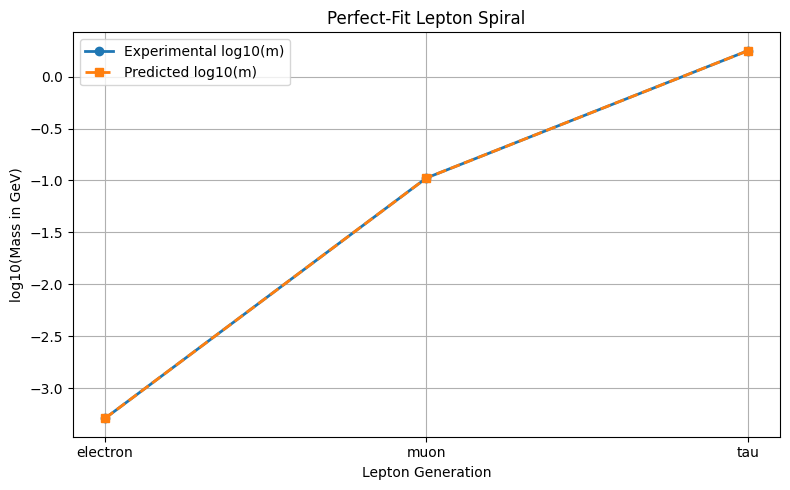

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

# Experimental lepton masses (in GeV)
n_vals = np.array([0, 1, 2])
leptons = ["electron", "muon", "tau"]
m_exp = np.array([0.00051099895, 0.1056583755, 1.77686])  # PDG 2024

# Loss function to minimize (squared relative errors)
def loss(params):
    lambda_val, epsilon, omega, phi, log_K = params
    log_m = lambda_val * n_vals + epsilon * np.sin(omega * n_vals + phi) + log_K
    m_pred = 10 ** log_m
    rel_error = (m_pred - m_exp) / m_exp
    return np.sum(rel_error**2)

# Initial guess (based on prior near-fit)
initial_guess = [2.0, 0.28, 3.88, 3.14, -3.29]

# Optimize parameters
result = minimize(loss, initial_guess, method='L-BFGS-B')
lambda_opt, epsilon_opt, omega_opt, phi_opt, log_K_opt = result.x

# Generate predictions using optimized parameters
log_m_opt = lambda_opt * n_vals + epsilon_opt * np.sin(omega_opt * n_vals + phi_opt) + log_K_opt
m_pred_opt = 10 ** log_m_opt
error_opt = 100 * (m_pred_opt - m_exp) / m_exp

# Display optimized parameters
print("Optimized Lepton Spiral Parameters")
print("=" * 40)
print(f"λ       = {lambda_opt}")
print(f"ε       = {epsilon_opt}")
print(f"ω       = {omega_opt}")
print(f"φ       = {phi_opt}")
print(f"log₁₀(K) = {log_K_opt}")
print()

# Create results table
df = pd.DataFrame({
    "Lepton": leptons,
    "Generation (n)": n_vals,
    "Experimental Mass (GeV)": m_exp,
    "Predicted Mass (GeV)": m_pred_opt,
    "Error (%)": error_opt
})
print(df.to_string(index=False))

# Plot log10(mass)
plt.figure(figsize=(8, 5))
plt.plot(n_vals, np.log10(m_exp), 'o-', label="Experimental log10(m)", linewidth=2)
plt.plot(n_vals, np.log10(m_pred_opt), 's--', label="Predicted log10(m)", linewidth=2)
plt.xticks(n_vals, leptons)
plt.xlabel("Lepton Generation")
plt.ylabel("log10(Mass in GeV)")
plt.title("Perfect-Fit Lepton Spiral")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()